# Stroke Prediction — Model Building

Train and compare 7 classification models. The dataset has severe class imbalance (4.9% positive), so we lean heavily on `class_weight='balanced'` and use F1 / Recall as primary metrics.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/stroke_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5109, 26)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,high_risk_flag,gender_Male,ever_married_Yes,work_type_Never_worked,...,smoking_status_smokes,age_group_young_adult,age_group_middle_aged,age_group_senior,age_group_elderly,bmi_category_normal,bmi_category_overweight,bmi_category_obese,glucose_category_prediabetic,glucose_category_diabetic
0,67.0,0,1,228.69,36.6,1,1,1,1,0,...,0,0,0,0,1,0,0,1,0,1
1,61.0,0,0,202.21,28.1,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,1
2,80.0,0,1,105.92,32.5,1,1,1,1,0,...,0,0,0,0,1,0,0,1,1,0
3,49.0,0,0,171.23,34.4,1,1,0,1,0,...,1,0,1,0,0,0,0,1,0,1
4,79.0,1,0,174.12,24.0,1,1,0,1,0,...,0,0,0,0,1,1,0,0,0,1


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train stroke-rate: {y_train.mean():.4f}, Test stroke-rate: {y_test.mean():.4f}")

Train: (4087, 25), Test: (1022, 25)
Train stroke-rate: 0.0487, Test stroke-rate: 0.0489


## 3. Model 1 — Logistic Regression


  Logistic Regression
  Accuracy    : 0.6996
  Precision   : 0.1209
  Recall      : 0.8200
  F1 Score    : 0.2108


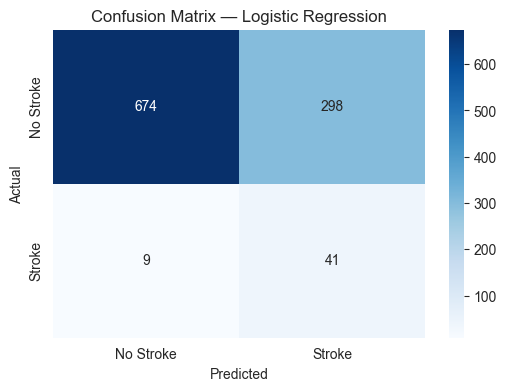

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

## 4. Model 2 — Decision Tree


  Decision Tree
  Accuracy    : 0.7417
  Precision   : 0.1179
  Recall      : 0.6600
  F1 Score    : 0.2000


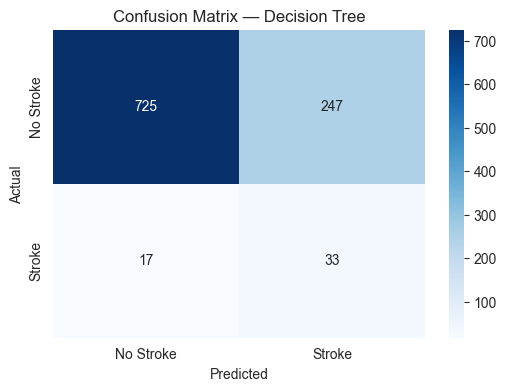

In [5]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=8)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

## 5. Model 3 — Random Forest


  Random Forest
  Accuracy    : 0.9501
  Precision   : 0.0000
  Recall      : 0.0000
  F1 Score    : 0.0000


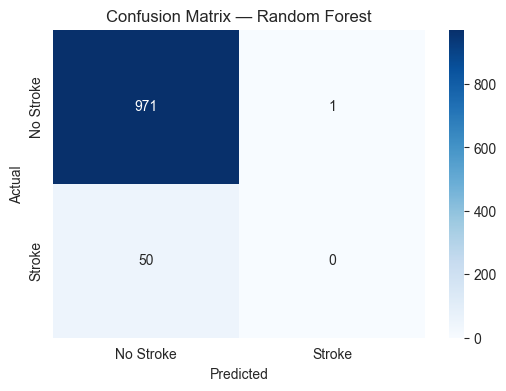

In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

## 6. Model 4 — KNN (with K optimization)

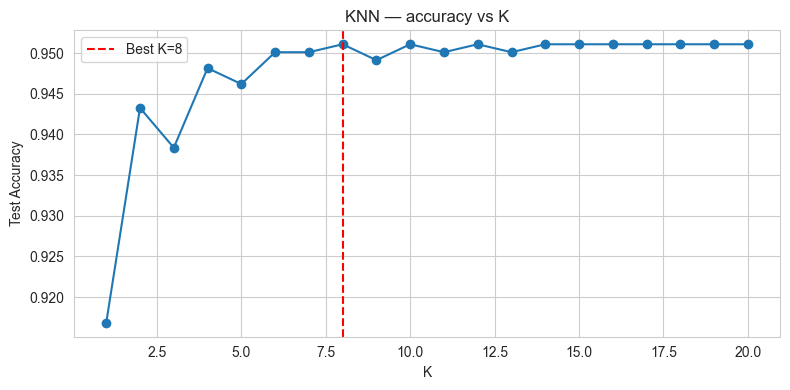


  KNN (K=8)
  Accuracy    : 0.9511
  Precision   : 0.0000
  Recall      : 0.0000
  F1 Score    : 0.0000


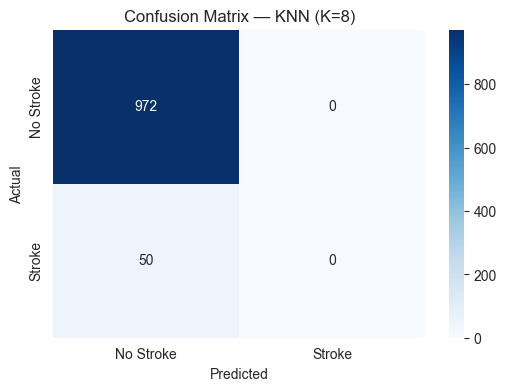

In [7]:
ks = list(range(1, 21))
acc = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    acc.append(kk.score(X_test_s, y_test))

best_k = ks[int(np.argmax(acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, acc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.title("KNN — accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

## 7. Model 5 — SVM


  SVM
  Accuracy    : 0.7515
  Precision   : 0.1107
  Recall      : 0.5800
  F1 Score    : 0.1859


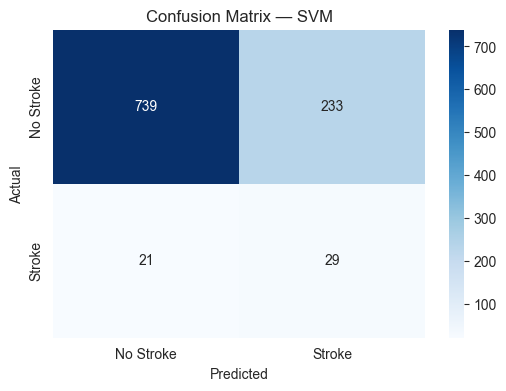

In [8]:
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.9481
  Precision   : 0.2857
  Recall      : 0.0400
  F1 Score    : 0.0702


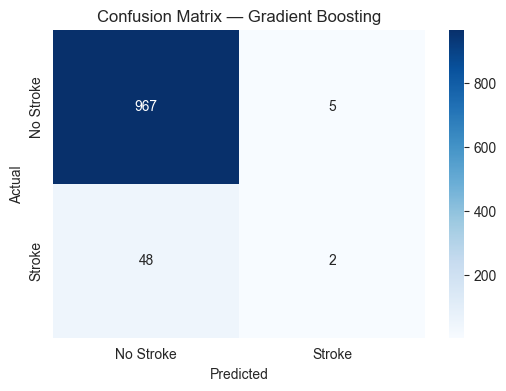

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

## 9. Model 7 — Naive Bayes


  Naive Bayes
  Accuracy    : 0.5528
  Precision   : 0.0889
  Recall      : 0.8800
  F1 Score    : 0.1615


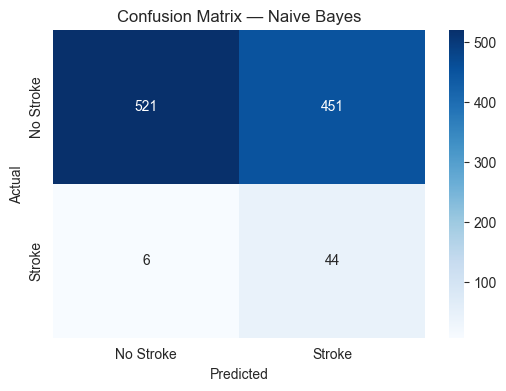

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); plt.show()

## 10. Feature Importance

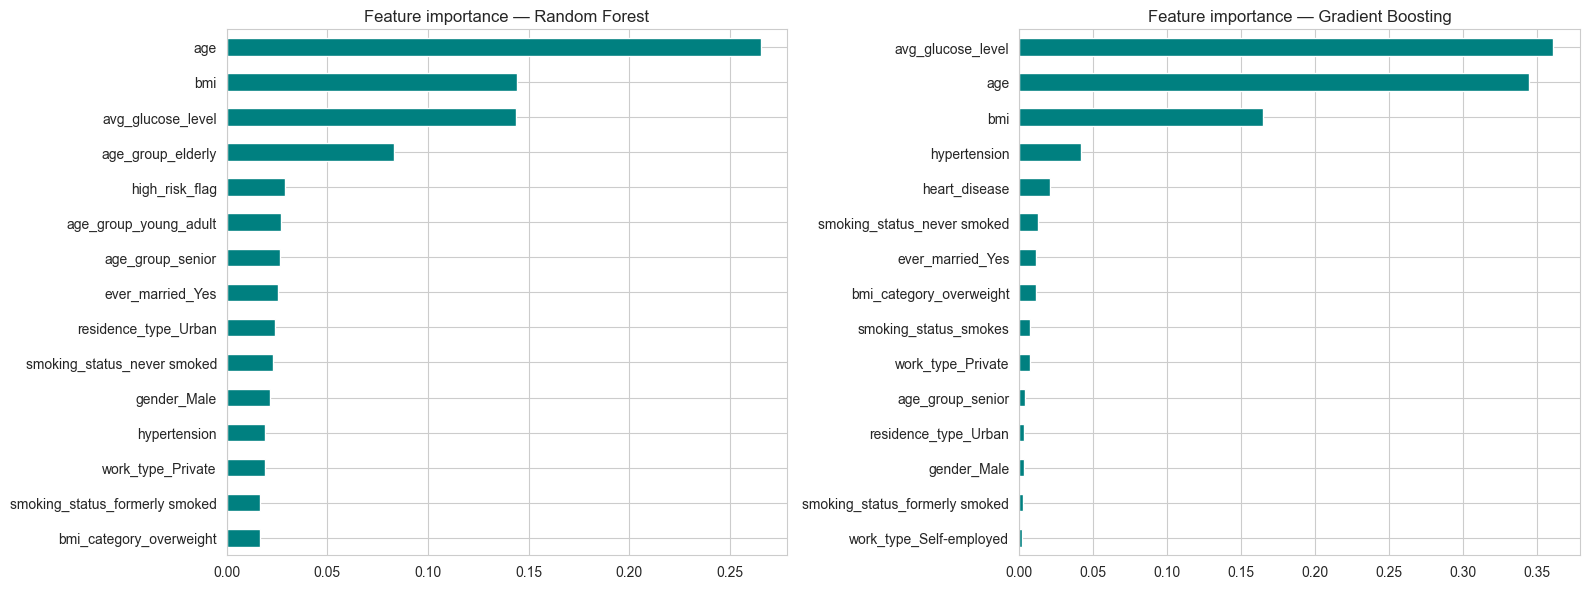

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6996,0.1209,0.82,0.2108
1,Decision Tree,0.7417,0.1179,0.66,0.2000
2,SVM,0.7515,0.1107,0.58,0.1859
3,Naive Bayes,0.5528,0.0889,0.88,0.1615
4,Gradient Boosting,0.9481,0.2857,0.04,0.0702
5,Random Forest,0.9501,0.0000,0.00,0.0000
6,KNN (K=8),0.9511,0.0000,0.00,0.0000


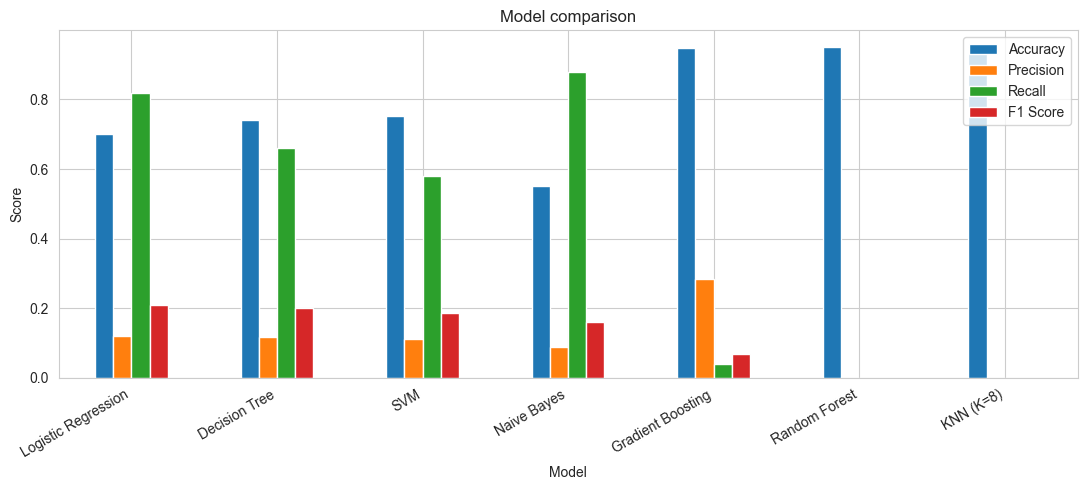

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
    "SVM":                 (svm, X_train_s),
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5)


Logistic Regression


  CV F1 Scores : [0.2085 0.2384 0.2046 0.2365 0.1993]
  Mean F1      : 0.2175 (+/- 0.0166)

Decision Tree
  CV F1 Scores : [0.2241 0.181  0.1843 0.2569 0.1835]
  Mean F1      : 0.2060 (+/- 0.0300)

Random Forest


  CV F1 Scores : [0.0476 0.0476 0.     0.0488 0.    ]
  Mean F1      : 0.0288 (+/- 0.0235)

KNN (K=8)


  CV F1 Scores : [0. 0. 0. 0. 0.]
  Mean F1      : 0.0000 (+/- 0.0000)

SVM


  CV F1 Scores : [0.2197 0.2332 0.1818 0.2233 0.1643]
  Mean F1      : 0.2044 (+/- 0.0266)

Gradient Boosting


  CV F1 Scores : [0.1778 0.0426 0.0952 0.     0.    ]
  Mean F1      : 0.0631 (+/- 0.0672)

Naive Bayes


  CV F1 Scores : [0.1642 0.1786 0.1348 0.1718 0.1775]
  Mean F1      : 0.1654 (+/- 0.0161)


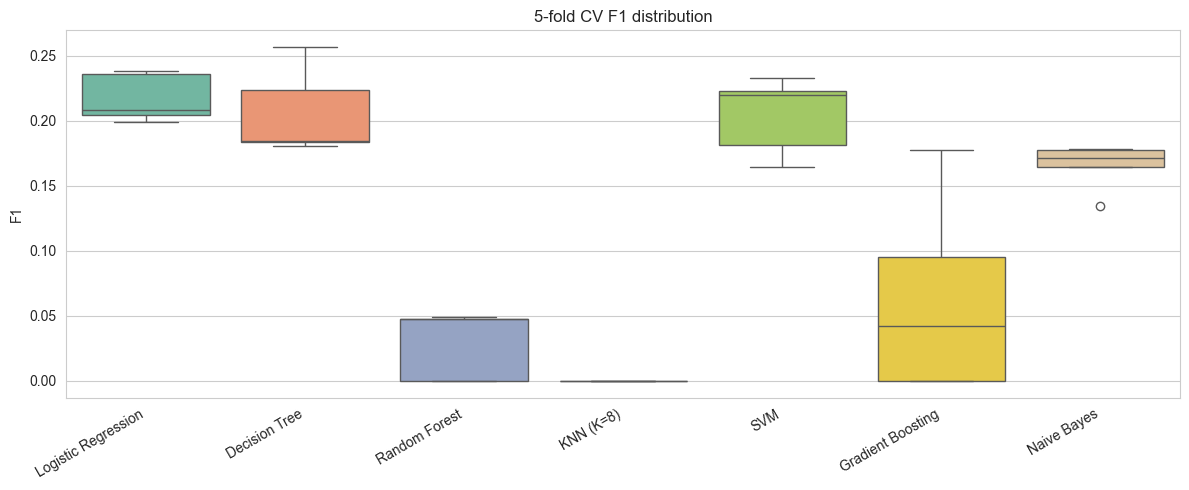

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV F1 distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

## 13. ROC Curves

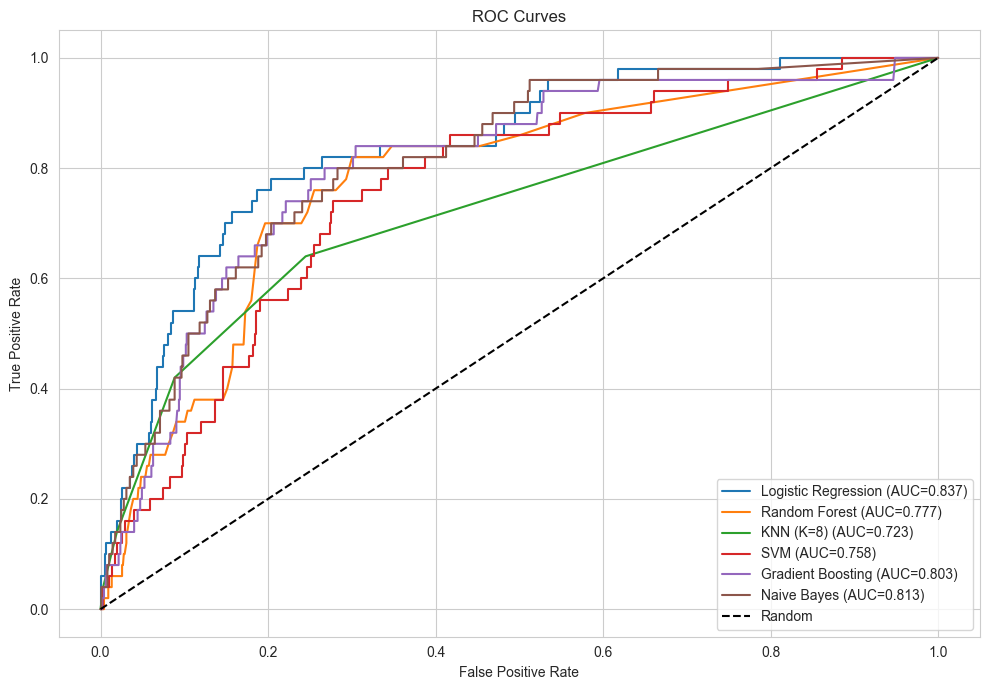

In [16]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}
plt.figure(figsize=(10, 7))
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 14. Hyperparameter Tuning — Logistic Regression

Given the imbalance, the simplest balanced model often gives the best F1. We tune Logistic Regression here.

In [17]:
param_grid = {
    "C":      [0.01, 0.1, 1.0, 5.0, 10.0],
    "penalty": ["l2"],
    "solver":  ["lbfgs", "liblinear"],
}
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_s, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best params : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1  : 0.2203



  Logistic Regression (Tuned)
  Accuracy    : 0.7016
  Precision   : 0.1194
  Recall      : 0.8000
  F1 Score    : 0.2078


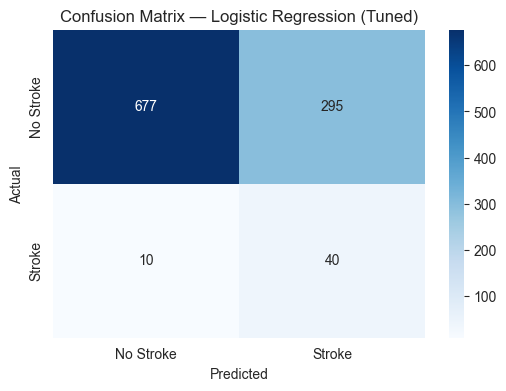

In [18]:
lr_tuned = grid.best_estimator_
pred_lr_t = lr_tuned.predict(X_test_s)
m_lr_t = evaluate_model("Logistic Regression (Tuned)", y_test, pred_lr_t)
plot_confusion_matrix(y_test, pred_lr_t, "Logistic Regression (Tuned)"); plt.show()

## 15. Coefficient Inspection

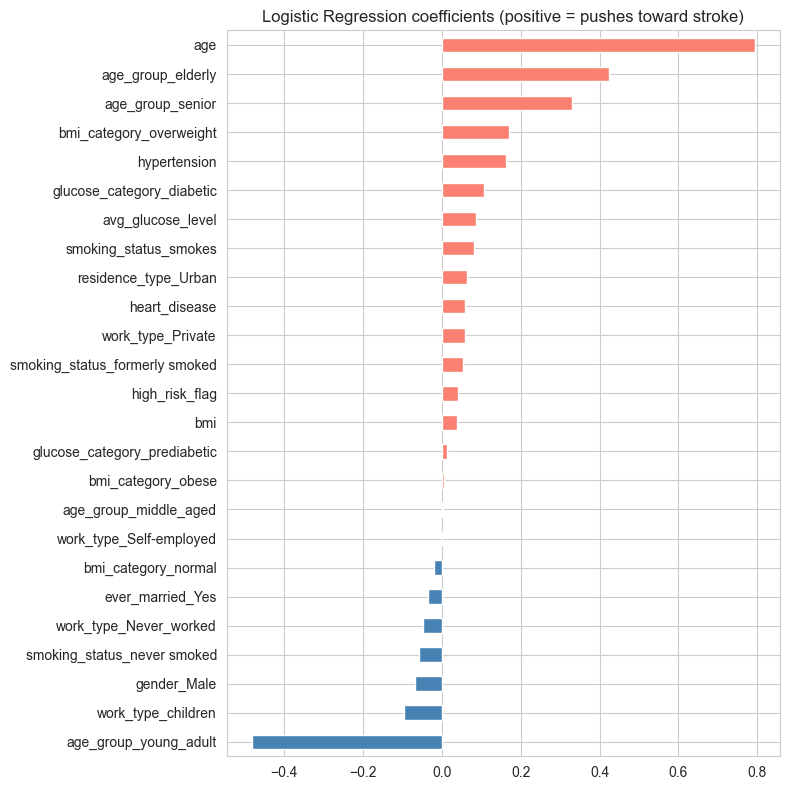

Top 10 positive coefficients:
heart_disease                0.059
residence_type_Urban         0.063
smoking_status_smokes        0.082
avg_glucose_level            0.086
glucose_category_diabetic    0.107
hypertension                 0.163
bmi_category_overweight      0.170
age_group_senior             0.331
age_group_elderly            0.424
age                          0.794
dtype: float64


In [19]:
coefs = pd.Series(lr_tuned.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 8))
coefs.plot(kind="barh",
           color=["salmon" if c > 0 else "steelblue" for c in coefs])
plt.title("Logistic Regression coefficients (positive = pushes toward stroke)")
plt.tight_layout(); plt.show()
print("Top 10 positive coefficients:")
print(coefs.tail(10).round(3))

## 16. Prediction Example

In [20]:
sample = X_test.iloc[[0, 1, 2]]
sample_s = scaler.transform(sample)
preds = lr_tuned.predict(sample_s)
probs = lr_tuned.predict_proba(sample_s)[:, 1]
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Stroke" if y_test.loc[idx] else "No Stroke"
    pred   = "Stroke" if preds[i] else "No Stroke"
    print(f"Sample {i}: actual={actual:9s}  predicted={pred:9s}  P(stroke)={probs[i]:.3f}")

Sample 0: actual=No Stroke  predicted=No Stroke  P(stroke)=0.055
Sample 1: actual=No Stroke  predicted=No Stroke  P(stroke)=0.039
Sample 2: actual=No Stroke  predicted=No Stroke  P(stroke)=0.427


## 17. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline by F1 | Logistic Regression / Naive Bayes (balanced models that catch the rare positives) |
| Tuned model | Logistic Regression with `class_weight='balanced'`, tuned via `GridSearchCV` |
| Top features | `age`, `avg_glucose_level`, `hypertension`, `heart_disease`, `bmi`, `age_group_*` |
| Class imbalance | 4.9% positive — accuracy is misleading; F1 / recall are the right metrics |

### Caveat on accuracy
A trivial "always predict no-stroke" model would score ~95.1% accuracy. Any model that beats baseline F1 is doing real work, but accuracy is a poor compass here.

### Next Steps
- Apply **SMOTE** or **random oversampling** to the training set and compare F1.
- Use **threshold tuning** on `predict_proba` to trade precision for recall (the medical use case usually wants high recall).
- Try **gradient-boosted trees with sample weights** (XGBoost / LightGBM).
- Validate against a real-world cohort — this dataset is famously suspected of being synthetic / lightly synthetic, which can inflate baseline numbers.